# Load package

In [1]:
import scimap as sm

import sys
import anndata as ad
import seaborn as sns; sns.set(color_codes=True)
import numpy as np

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

Running SCIMAP  2.2.11


# Load data

In [2]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_2.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_39940/1910434769.py:1: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



In [3]:
data.columns

Index(['S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4', 'FOXP3',
       'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin', 'H3K27me3',
       'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN', 'pSTAT3',
       'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid', 'imageid',
       'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI',
       'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1',
       'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM',
       'CellCategory'],
      dtype='object')

# Spatial Count

In [4]:
image_path = '/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_2.csv'
# Convert the data to scimap format
adata = sm.pp.mcmicro_to_scimap(image_path, 
                                remove_dna=False, remove_string_from_name=None, log=False, drop_markers=None,
                                random_sample=None, unique_CellId=True, CellId='CellID', split='X_centroid',
                                custom_imageid=None, min_cells=None, output_dir=None)
adata.obsm['spatial'] = np.array(adata.obs[['Y_centroid', 'X_centroid']])
adata

Loading Data_AllMarkers_filtered_2.csv


/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/scimap/preprocessing/mcmicro_to_scimap.py:106: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM', 'CellCategory', 'CellID', 'imageid'
    uns: 'all_markers'
    obsm: 'spatial'

In [5]:
adata = sm.tl.spatial_count(adata, phenotype='celltype_1', method='radius', radius=45, label='spatial_count_45px')

Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell


In [ ]:
adata = sm.tl.spatial_cluster(adata, df_name='spatial_count_45px', method='kmeans', k=10, label='SC45px_neigh_kmeans_10')

In [ ]:
adata.obs

In [ ]:
# First, create a mapping DataFrame from adata.obs with the columns we need
mapping_df = adata.obs[['CellID', 'core_imageid', 'SC45px_neigh_kmeans_10']]

# Reset the index of data if CellID is currently the index
data_reset = data.reset_index()

# Merge data with the mapping DataFrame using CellID as the key
merged_data = data.merge(mapping_df, on=['CellID', 'core_imageid'], how='left')

# Set CellID back as the index if needed
data = merged_data.set_index('CellID')

In [ ]:
data

In [ ]:
rename_dict = {'RCN1': ['2'],
               'RCN2': ['1'],
               'RCN3': ['4'],
               'RCN4': ['6'],
               'RCN5': ['7'],
               'RCN6': ['0'],
               'RCN7': ['3'],
               'RCN8': ['5'],
               'RCN9': ['8'],
               'RCN10': ['9']
                }

replace_dict= {v: k for k, values in rename_dict.items() for v in values}
data['SC45px_neigh_kmeans_10'] = data['SC45px_neigh_kmeans_10'].astype(str)
data['RCNs'] = data['SC45px_neigh_kmeans_10'].replace(replace_dict)

In [ ]:
data.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv')

# Elbow plot

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

def elbow_silhouette_plot(adata, df_name='spatial_count_45px', k_range=range(2, 15), subsample=5000, batch_size=1000):
    """
    Fast evaluation of different k clustering results (Elbow + Silhouette)
    
    Parameters:
    - adata: AnnData object
    - df_name: matrix name stored in obsm
    - k_range: range of k values, e.g., range(2,15)
    - subsample: number of samples for silhouette calculation, default 5000
    - batch_size: batch size for MiniBatchKMeans
    """
    
    X = adata.obsm[df_name]

    # Subsample for silhouette calculation
    if X.shape[0] > subsample:
        idx = np.random.choice(X.shape[0], size=subsample, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X

    sse = []
    silhouette_scores = []

    for k in k_range:
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=0, batch_size=batch_size).fit(X)
        sse.append(kmeans.inertia_)  # SSE

        # Calculate silhouette on subsampled data
        labels_sub = kmeans.predict(X_sub)
        silhouette_scores.append(silhouette_score(X_sub, labels_sub))

    # Plot results
    fig, ax1 = plt.subplots()

    color = "tab:blue"
    ax1.set_xlabel("Number of clusters k")
    ax1.set_ylabel("SSE (Elbow)", color=color)
    ax1.plot(list(k_range), sse, "o-", color=color)
    ax1.tick_params(axis="y", labelcolor=color)

    ax2 = ax1.twinx()
    color = "tab:orange"
    ax2.set_ylabel("Silhouette score", color=color)
    ax2.plot(list(k_range), silhouette_scores, "s--", color=color)
    ax2.tick_params(axis="y", labelcolor=color)

    plt.title("Elbow & Silhouette (MiniBatchKMeans, subsample={})".format(len(X_sub)))
    plt.show()

In [7]:
adata

AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM', 'CellCategory', 'CellID', 'imageid'
    uns: 'all_markers', 'spatial_count_45px'
    obsm: 'spatial'

In [6]:
adata.uns['all_markers']

['S9.6',
 'HER3',
 'panCK',
 'SMA',
 'CD45',
 'Ki67_2',
 'CD4',
 'FOXP3',
 'CD8a',
 'CD11b',
 'CD68',
 'CD206',
 'H2ax',
 'Vimentin',
 'H3K27me3',
 'E.Cadherin',
 'GCLC',
 'TXNRD1',
 'NQO1',
 'pERK',
 'TXN',
 'pSTAT3',
 'pS6_235',
 'pRB',
 'GLUT1']

In [28]:
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import numpy as np

def elbow_silhouette_plot(adata, df_name='spatial_count_45px', k_range=range(2,15), subsample=5000, batch_size=1000, savepath='elbow_silhouette_plot.pdf'):
    """
    快速评估不同k的聚类效果（Elbow + Silhouette）
    
    参数:
    - adata: AnnData对象
    - df_name: obsm中保存的矩阵名
    - k_range: k的范围，例如 range(2,15)
    - subsample: 用于计算silhouette的下采样数，默认5000
    - batch_size: MiniBatchKMeans的批大小
    """
    X = adata.uns[df_name]

    # 下采样（用于 silhouette）
    if isinstance(X, np.ndarray):
    # 如果本身是 numpy 数组
        if X.shape[0] > subsample:
            idx = np.random.choice(X.shape[0], size=subsample, replace=False)
            X_sub = X[idx, :]
        else:
            X_sub = X
    else:
    # 如果是 DataFrame
        if X.shape[0] > subsample:
            idx = np.random.choice(X.shape[0], size=subsample, replace=False)
            X_sub = X.iloc[idx, :].values  # 注意用 iloc 并转成 numpy
        else:
            X_sub = X.values


    sse = []
    silhouette_scores = []

    for k in k_range:
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=0, batch_size=batch_size).fit(X)
        sse.append(kmeans.inertia_)  # SSE

        # 用下采样数据算 silhouette
        labels_sub = kmeans.predict(X_sub)
        silhouette_scores.append(silhouette_score(X_sub, labels_sub))

    # 画图
    fig, ax1 = plt.subplots()
    
    ax1.set_facecolor('white')

    color = "tab:blue"
    ax1.set_xlabel("Number of clusters k")
    ax1.set_ylabel("SSE (Elbow)", color=color)
    ax1.plot(list(k_range), sse, "o-", color=color)
    ax1.tick_params(axis="y", labelcolor=color)

    ax2 = ax1.twinx()
    ax2.set_facecolor('white')
    color = "tab:orange"
    ax2.set_ylabel("Silhouette score", color=color)
    ax2.plot(list(k_range), silhouette_scores, "s--", color=color)
    ax2.tick_params(axis="y", labelcolor=color)

    ax1.grid(True, color="lightgray", linestyle="--", linewidth=0.5)
    ax2.grid(False)
    
    for spine in ax1.spines.values():
        spine.set_visible(True)
    for spine in ax2.spines.values():
        spine.set_visible(True) 

    plt.title("Elbow & Silhouette (MiniBatchKMeans, subsample={})".format(len(X_sub)))
    plt.tight_layout()  # Ensure proper spacing
    plt.savefig(savepath, format='pdf', bbox_inches='tight', dpi=500)
    plt.show()


/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MiniBatchKMeans was fitted with feature names

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MiniBatchKMeans was fitted with feature names

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MiniBatchKMeans was fitted with feature names

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MiniBatchKMeans was fitted with feature names

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MiniBatchKMe

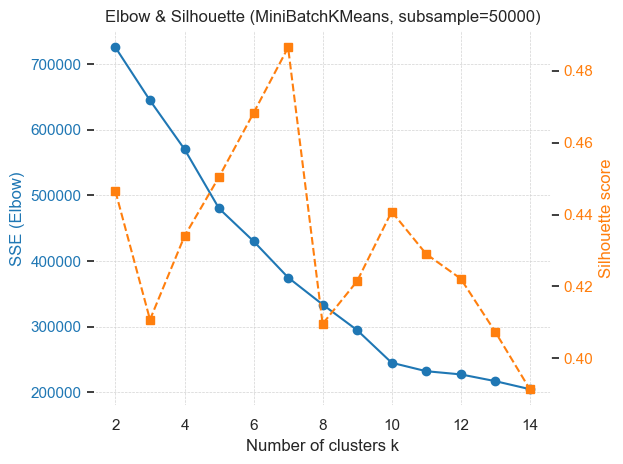

In [30]:
elbow_silhouette_plot(adata, df_name='spatial_count_45px', k_range=range(2,15), subsample=50000, savepath='/Users/wenqchen/Desktop/Projects/Auria/Plots/elbow_silhouette_plot_3.pdf')

In [11]:
X = adata.uns['spatial_count_45px']
X

neighbour_phenotype,CD206.Macrophages,CD4.T.cells,CD68.Macrophages,CD8.T.cells,Other.Immune,Other.Stroma,SMA+.Stroma,Treg,Tumor,VIM+.Stroma
19_02_02A_1,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.0
19_02_01A_10,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.0
19_02_02A_10,0.0,0.000000,0.083333,0.000000,0.083333,0.833333,0.0,0.000000,0.000000,0.0
19_02_01A_100,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.0
19_02_02A_100,0.0,0.176471,0.000000,0.000000,0.176471,0.647059,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...
INF1_99998,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.0
1B_99999,0.0,0.230769,0.076923,0.076923,0.076923,0.000000,0.0,0.076923,0.461538,0.0
2B_99999,0.0,0.062500,0.312500,0.000000,0.000000,0.000000,0.0,0.062500,0.562500,0.0
3B_99999,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.0


In [12]:
X.shape

(3681772, 10)